# Run Water Fraction Experiments

Group A – Baseline Quality Filtering<br>
* A1 – No filtering: All available pixels retained.
* A2 – Bad pixels removed.
* A3 – Bad + degraded pixels removed.
* A4 – Bad + degraded + suspicious pixels removed (most restrictive).

Group B – Alternative Filtering Approaches
* B1 – Default filtering: Using the general quality flag.
* B2 – Bitwise filtering: Bad pixels were removed ignoring the no_pixels bitwise flag.
* B3 – Geometric inner-swath exclusion: Pixels inside ±10 km of nadir removed by a geometric approach, instead of using the inner_swath flag.
* B4 – Combined filtering: Applying bitwise and geometric filters jointly.


## Imports

In [1]:
%load_ext autoreload
%autoreload 2

from tqdm.auto import tqdm

import pickle

from swot_toolkit.swot import create_raster_mosaic_combined
from swot_toolkit.analysis import open_sites_and_dates
from swot_toolkit.pipe2 import open_output_dir, open_roi
from swot_toolkit.pipe4 import calc_swot_metrics, open_datasets, quality_flags_bad
from swot_toolkit.water_frac import WaterFraction
from swot_toolkit.flags import Scenarios


In [2]:
sites_dates = open_sites_and_dates("/data/swot/output")
sites_dates

{'Curua-Una': ['2024-07-13', '2025-08-14'],
 'Northeast': ['2024-05-29', '2025-07-20'],
 'Rio_Branco': ['2024-04-03', '2025-09-07'],
 'Rio_Madeira': ['2024-08-21', '2025-07-21'],
 'Rio_Negro': ['2024-11-29', '2025-08-07']}

In [3]:
water_frac = WaterFraction("Curua-Una", "2024-07-13")

Reading KML file: /data/swot/output/Curua-Una/kml/Curua-Una.kml


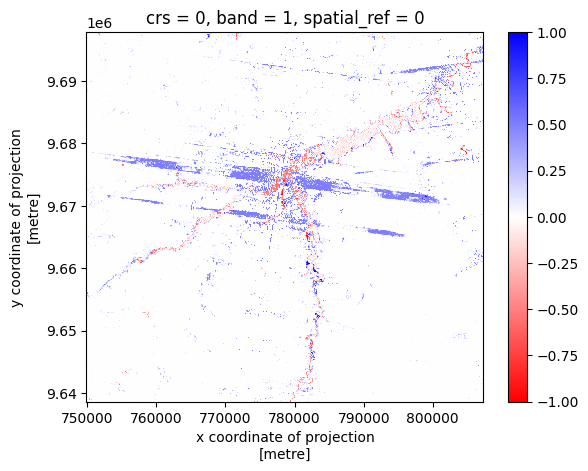

In [73]:
residuals = water_frac.template - water_frac.ref_mask()
residuals.plot(cmap="bwr_r")

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
water_frac.clear_cache()
swot, patches = water_frac.swot(Scenarios.A.BAD_DEG_SUSP_REMOVED, Scenarios.B.BITWISE)

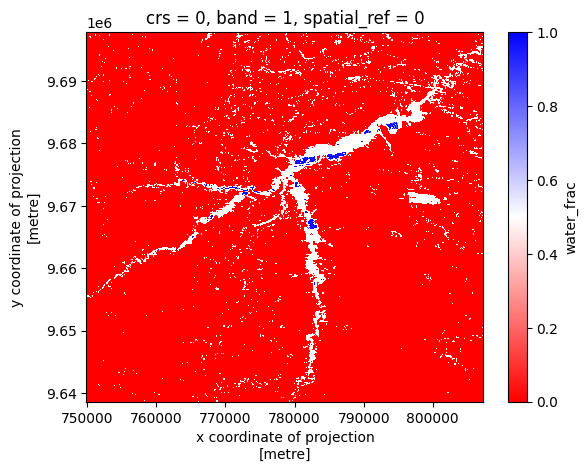

In [80]:
swot.plot(cmap="bwr_r")

In [82]:
residuals = swot - water_frac.ref_mask()

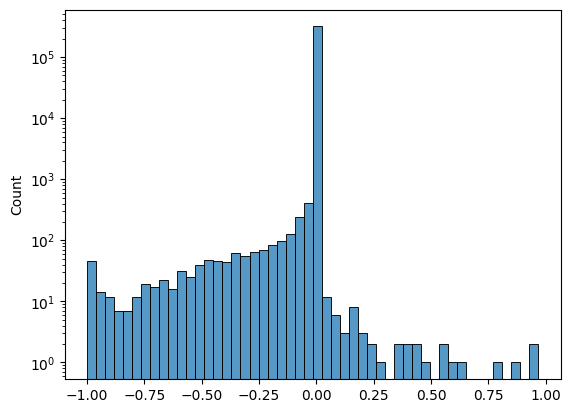

In [90]:
fig, ax = plt.subplots()
sns.histplot(residuals.to_numpy().flatten(), bins=50, log_scale=(False, False), kde=False, ax=ax)
ax.set_yscale("log", nonpositive="clip")

In [ ]:
import numpy as np

residuals_dict = {}
for scenario in Scenarios:
    swot, patches = water_frac.swot(scenario.a, scenario.b)
    swot_valid, ref_valid = WaterFraction.get_valid_pairs(swot, water_frac.ref_mask())
    residuals_dict[scenario.a, scenario.b] = swot_valid - ref_valid


In [115]:
data = []
labels = []
for sc_a in Scenarios.A:
    for sc_b in Scenarios.B:
        if sc_a is Scenarios.A.NO_FILTERING and sc_b is not Scenarios.B.DEFAULT:
            continue

        data.append(residuals_dict[sc_a, sc_b])
        labels.append(f"{sc_a.name}, {sc_b.name}")

        print(f"{sc_a.name}, {sc_b.name}: {residuals_dict[sc_a, sc_b].mean():.4f}")

NO_FILTERING, DEFAULT: -0.0880
BAD_REMOVED, DEFAULT: -0.1736
BAD_REMOVED, BITWISE: -0.0911
BAD_REMOVED, GEOMETRIC: -0.0817
BAD_REMOVED, BITWISE_GEOMETRIC: -0.0417
BAD_DEG_REMOVED, DEFAULT: -0.1736
BAD_DEG_REMOVED, BITWISE: -0.0911
BAD_DEG_REMOVED, GEOMETRIC: -0.0817
BAD_DEG_REMOVED, BITWISE_GEOMETRIC: -0.0417
BAD_DEG_SUSP_REMOVED, DEFAULT: 0.6177
BAD_DEG_SUSP_REMOVED, BITWISE: 0.6177
BAD_DEG_SUSP_REMOVED, GEOMETRIC: 0.6182
BAD_DEG_SUSP_REMOVED, BITWISE_GEOMETRIC: 0.6187


In [117]:
data.reverse()
labels.reverse()

/tmp/ipykernel_65497/1157823185.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plot = ax.boxplot(data, labels=labels, vert=False, showfliers=False)


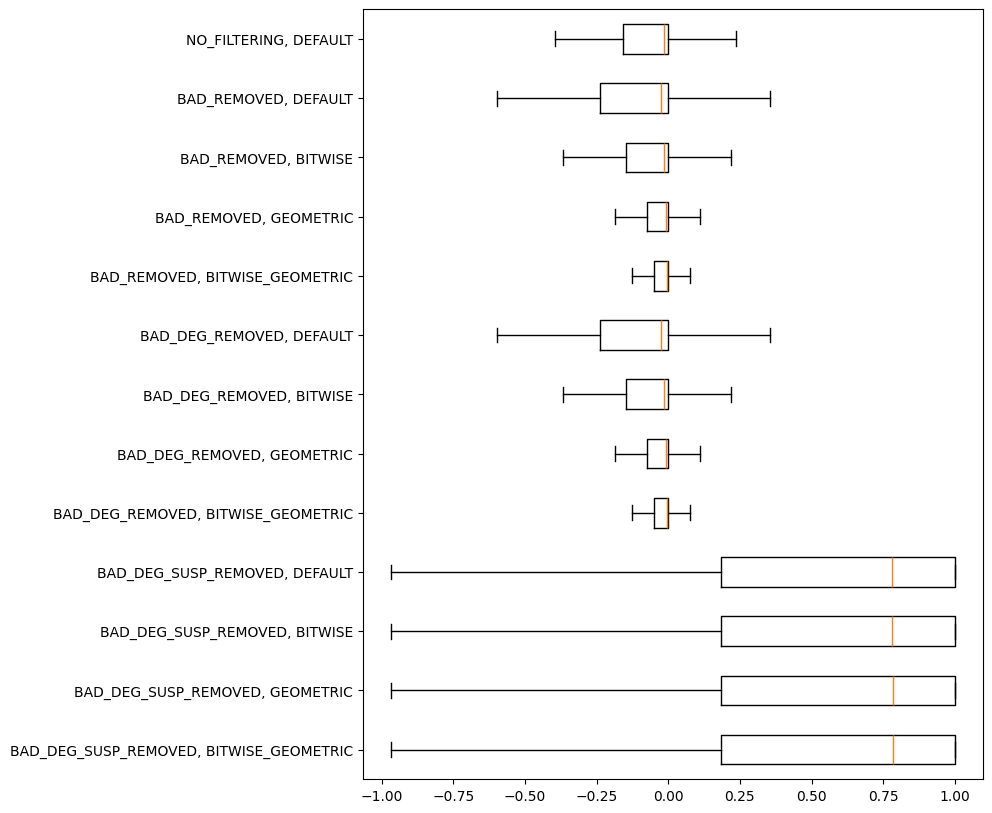

In [121]:
fig, ax = plt.subplots(figsize=(8, 10))
plot = ax.boxplot(data, labels=labels, vert=False, showfliers=False)

[autoreload of swot_toolkit.flags failed: Traceback (most recent call last):
  File "/workspaces/swot/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/workspaces/swot/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 621, in superreload
    update_generic(old_obj, new_obj)
  File "/workspaces/swot/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 447, in update_generic
    update(a, b)
  File "/workspaces/swot/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 415, in update_class
    update_instances(old, new)
  File "/workspaces/swot/.venv/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 373, in update_instances
    object.__setattr__(ref, "__class__", new)
TypeError: can't apply this __setattr__ to _ScenariosMeta object
]
/tmp/ipykernel_65497/97365902.py:22: MatplotlibDeprecationWarning: The 'label

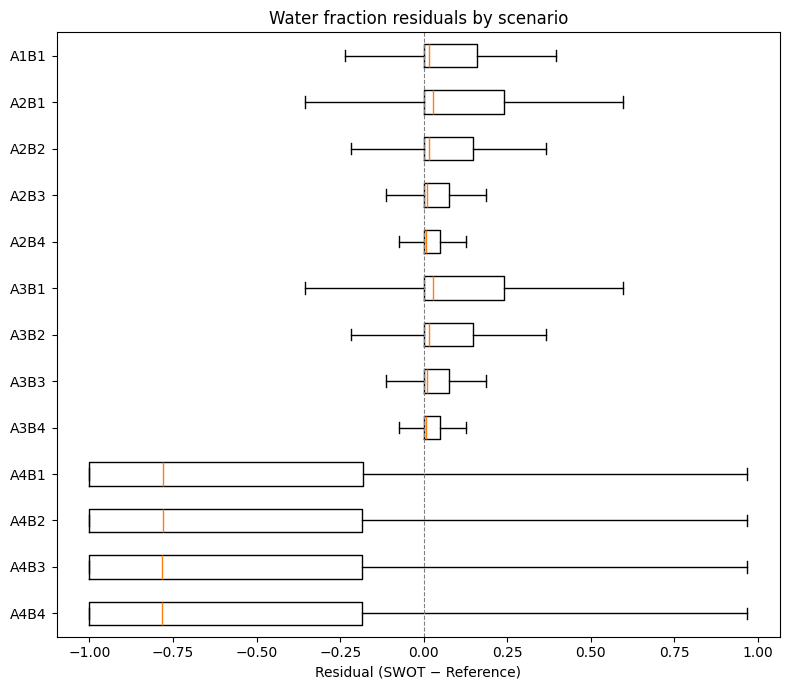

,Scenario (full),Bias,MAE,RMSE,N
Pair,,,,,
A1B1,"No filtering, Default filtering",0.088013,0.144409,0.237427,57326
A2B1,"Bad removed, Default filtering",0.173584,0.217407,0.379883,56343
A2B2,"Bad removed, Bitwise filtering",0.091064,0.136963,0.232178,56343
A2B3,"Bad removed, Geometric filtering",0.081665,0.147461,0.293945,40384
A2B4,"Bad removed, Bitwise+Geometric",0.041718,0.109558,0.214966,40384
A3B1,"Bad + Deg removed, Default filtering",0.173584,0.217407,0.379883,56343
A3B2,"Bad + Deg removed, Bitwise filtering",0.091064,0.136963,0.232178,56343
A3B3,"Bad + Deg removed, Geometric filtering",0.081665,0.147461,0.293945,40384
A3B4,"Bad + Deg removed, Bitwise+Geometric",0.041718,0.109558,0.214966,40384


In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

water_frac.clear_cache()

# --- Collect residuals and metrics for each scenario ---
results = {}
for sc in Scenarios:
    results[sc] = water_frac.process_scenario(sc.a, sc.b)

# --- Boxplot with abbreviated labels (A1B1, A2B1, …) ---
pairs = list(results.keys())
data_bp = [results[sc]["residuals"] for sc in pairs]
labels_bp = [sc.name for sc in pairs]

# Reverse so A1B1 is at top
data_bp = data_bp[::-1]
labels_bp = labels_bp[::-1]

fig, ax = plt.subplots(figsize=(8, 7))
ax.boxplot(data_bp, labels=labels_bp, vert=False, showfliers=False)
ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Residual (SWOT − Reference)")
ax.set_title("Water fraction residuals by scenario")
plt.tight_layout()
plt.show()

# --- Metrics DataFrame ---
rows = [
    {
        "Scenario (full)": sc.full_name,
        "Pair": sc.name,
        "Bias": results[sc]["Bias"],
        "MAE": results[sc]["MAE"],
        "RMSE": results[sc]["RMSE"],
        "N": results[sc]["N"],
    }
    for sc in pairs
]
pd.DataFrame(rows).set_index("Pair")


In [81]:
residuals = swot - water_frac.ref_mask()

## Main loop with all sites

In this main loop, we will loop through all the sites/dates and gather all data as 1-dim vectors, in numpy. 
We will do this to speed up the process of comparing the water fractions. 

At the end, all the sites will be assessed together.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rasterio.enums import Resampling


# -------------------------------------------------
# Helper: extract valid paired pixels
# -------------------------------------------------
def get_valid_pairs(raster, ref_mask):
    # Reproject reference to match current raster
    ref_water_fraction = ref_mask.where(ref_mask != 2).rio.reproject_match(
        raster,
        resampling=Resampling.average,
    )

    ref = np.asarray(ref_water_fraction).squeeze().astype(np.float16)
    sat = np.asarray(raster).squeeze().astype(np.float16)

    if ref.shape != sat.shape:
        raise ValueError(f"Shape mismatch: ref={ref.shape}, sat={sat.shape}")

    ref = ref.ravel()
    sat = sat.ravel()

    # Fill sat values as no water. This allows us to keep pixels where ref is valid but sat is not,
    # which is important for bias calculation.
    sat = np.nan_to_num(sat, nan=0)
    sat[sat > 1] = 1
    sat[sat < 0] = 0

    mask = np.isfinite(ref) & np.isfinite(sat)
    # mask &= (ref > 0) | (sat > 0)
    # mask &= (ref < 1) | (sat < 1)

    # & (ref >= 0) & (ref <= 1) & (sat >= 0) & (sat <= 1)

    return ref[mask], sat[mask]


# -------------------------------------------------
# Helper: metrics
# -------------------------------------------------
def calc_metrics_from_arrays(ref_valid, sat_valid):
    residuals = sat_valid - ref_valid

    bias = residuals.mean()
    mae = np.abs(residuals).mean()
    rmse = np.sqrt(np.mean(residuals**2))

    return {
        "Bias": bias,
        "MAE": mae,
        "RMSE": rmse,
        "N": len(residuals),
        "residuals": residuals,
    }


def get_data_for_scenario(scenario_A, scenario_B):
    # Implement the function to get data for a specific scenario
    filtering_params = get_filtering_params(scenario_A, scenario_B)

    # Init arrays to hold all valid pairs across sites/dates for this scenario
    ref_valid = np.array([])
    sat_valid = np.array([])
    data = {}

    for site, dates in sites_dates.items():
        for date in dates:
            # --- Open datasets ---
            datasets = open_datasets(
                site, date, s2=False, ref=True, opera_s2=False, opera_s1=False
            )
            ref_mask = datasets["ref_mask"]
            del datasets

            # --- Open ROI info ---
            base_dir, aoi, mosaic_df = open_roi(site)

            raster, patches, no_data_masks = create_raster_mosaic_combined(
                mosaic_df=mosaic_df,
                ref_date=date,
                aoi=aoi,
                **filtering_params,
            )

            for i, patch in enumerate(patches):
                ref_valid_site, sat_valid_site = get_valid_pairs(patch["water_frac"], ref_mask)
                ref_valid = np.concat([ref_valid, ref_valid_site]).astype(np.float16)
                sat_valid = np.concat([sat_valid, sat_valid_site]).astype(np.float16)

    # Once we have all valid pairs for the scenario, we can calculate metrics
    metrics = calc_metrics_from_arrays(ref_valid, sat_valid)
    data["metrics"] = metrics
    data["ref_valid"] = ref_valid
    data["sat_valid"] = sat_valid

    return data


In [319]:
# --- Loop through scenarios ---
data = {}

for i, scenario_A in enumerate(scenarios_A.keys()):
    for j, scenario_B in enumerate(scenarios_B.keys()):
        if i == 0 and j != 0:
            # Skip scenario A1B2-4 since it's just for reference (handled in scenario B)
            continue

        experiment_name = f"A{i + 1}B{j + 1}"
        print(f"  {experiment_name} - {scenario_A}/{scenario_B}")
        data[experiment_name] = get_data_for_scenario(scenario_A, scenario_B)


  A1B1 - No filtering/Default filtering
  A2B1 - Bad removed/Default filtering
  A2B2 - Bad removed/Bitwise filtering
  A2B3 - Bad removed/Geometric filtering
  A2B4 - Bad removed/Bitwise+Geometric
  A3B1 - Bad + Deg removed/Default filtering
  A3B2 - Bad + Deg removed/Bitwise filtering
  A3B3 - Bad + Deg removed/Geometric filtering
  A3B4 - Bad + Deg removed/Bitwise+Geometric
  A4B1 - Bad + Deg + Susp removed/Default filtering
  A4B2 - Bad + Deg + Susp removed/Bitwise filtering
  A4B3 - Bad + Deg + Susp removed/Geometric filtering
  A4B4 - Bad + Deg + Susp removed/Bitwise+Geometric


In [320]:
with open("scenario_comparison_data.pkl", "wb") as f:
    pickle.dump(data, f)

In [6]:
# Load the data
with open("scenario_comparison_data.pkl", "rb") as f:
    data = pickle.load(f)

In [7]:
data.keys()

dict_keys(['A1B1', 'A2B1', 'A2B2', 'A2B3', 'A2B4', 'A3B1', 'A3B2', 'A3B3', 'A3B4', 'A4B1', 'A4B2', 'A4B3', 'A4B4'])

In [8]:
len(data)

13

## Plot histograms

In [13]:
import seaborn as sns

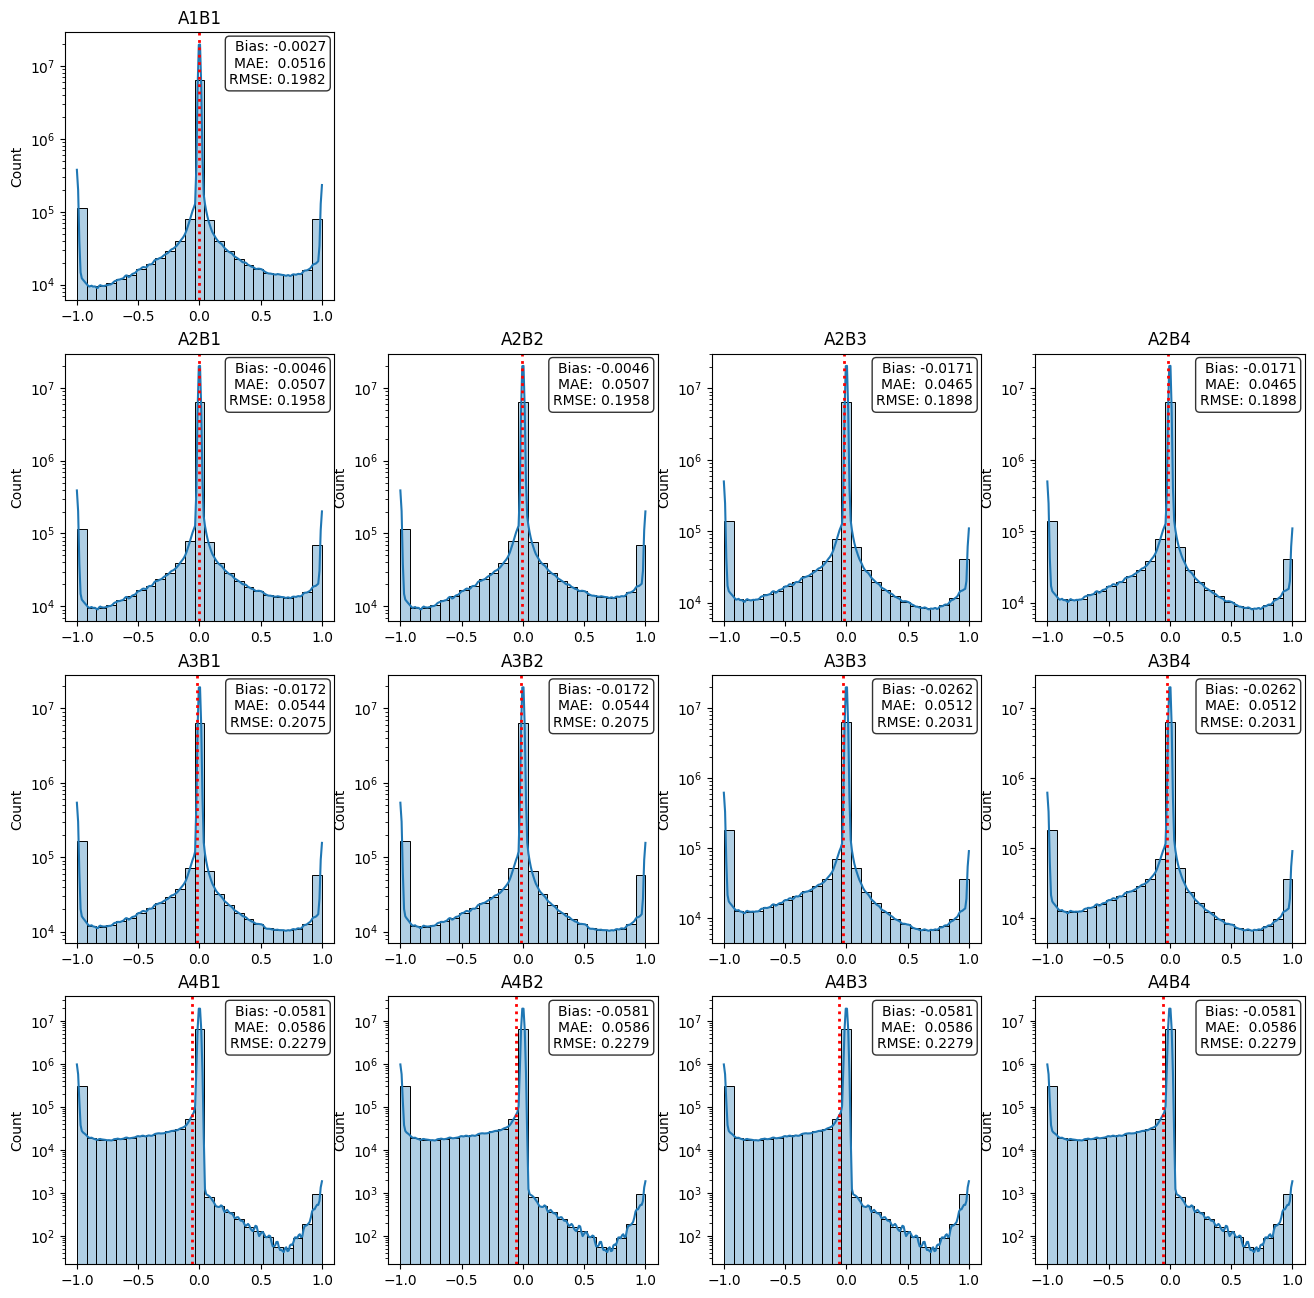

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(16, 16))

for experiment, values in data.items():
    row = int(experiment[1])
    col = int(experiment[3])
    ax = axs[row - 1, col - 1]

    residuals = values["metrics"]["residuals"]
    bias = values["metrics"]["Bias"]
    mae = values["metrics"]["MAE"]
    rmse = values["metrics"]["RMSE"]

    sns.histplot(
        residuals,
        bins=25,
        log_scale=(False, True),
        kde=True,
        ax=ax,
        stat="count",
        alpha=0.35,  # more transparency so KDE stands out
    )

    # Vertical dotted line for bias
    ax.axvline(
        bias,
        color="red",
        linestyle=":",
        linewidth=2,
        label="Bias",
    )

    ax.set_yscale("log", nonpositive="clip")

    # Info box inside the plot
    info_text = f"Bias: {bias:.4f}\nMAE:  {mae:.4f}\nRMSE: {rmse:.4f}"

    ax.text(
        0.97,
        0.97,
        info_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor="black",
            alpha=0.8,
        ),
    )

    ax.set_title(experiment)

for ax in axs[0, 1:]:
    ax.set_visible(False)

plt.show()

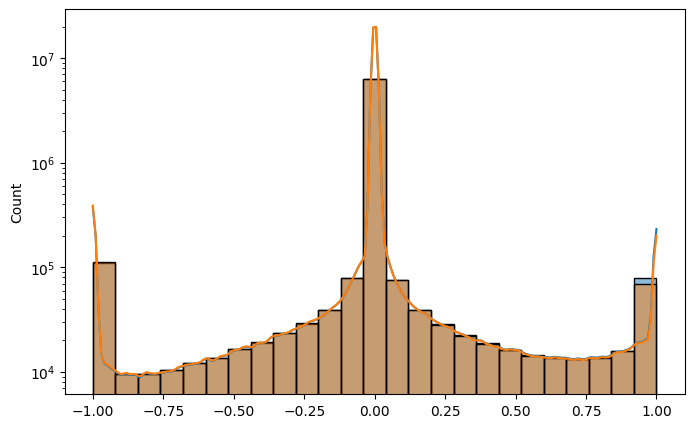

In [ ]:
fig, axs = plt.subplots(4, 4, figsize=(20, 20))

for experiment, values in data.items():
    row = int(experiment[1])
    col = int(experiment[3])
    ax = axs[row - 1, col - 1]

    sns.histplot(
        values["metrics"]["residuals"],
        bins=25,
        log_scale=(False, True),
        kde=True,
        ax=ax,
        stat="count",
    )
    sns.histplot(
        values["metrics"]["residuals"],
        bins=25,
        log_scale=(False, True),
        kde=False,
        ax=ax,
        stat="count",
    )

    ax.set_yscale("log", nonpositive="clip")


In [ ]:
results = {}
for experiment, metrics in data.items():
    results[experiment] = metrics["metrics"]


pd.DataFrame(results).T[["Bias", "MAE", "RMSE", "N"]]

,Bias,MAE,RMSE,N
A1B2,-0.002699,0.051605,0.198242,7078403
A2B2,-0.004578,0.050659,0.195801,7078403
A3B2,-0.017181,0.054413,0.20752,7078403
A4B2,-0.058075,0.058563,0.227905,7078403
